In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Inspection

In [2]:
df = pd.read_csv("C:\Machine_Learning_Projects\energy-load-forecasting\smart-household-energy-forecasting\data\processed\data.csv")
df.head(3)

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


In [3]:
df.tail(3)

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075256,2010-11-26 21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,2010-11-26 21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2075258,2010-11-26 21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [4]:
# Global active power: Total electricity consumed by the house, unit: kilowatt -> Target variable
# Global reactive power: power that is not directly used but supports the system. unit: kilowatt reactive(VAR)
# Voltage: Electrical pressure in the system. unit: Voltage (V)
# Global intensity (Current): Current flowing through the system. unit: Ampere (A)
# Sub-metering-1: energy consumed by kitchen circuit
# Sub-metering-2: energy consumed by laundry applicances
# Sub-metering-3: energy consumed by water-heater and AC

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Datetime               object 
 1   Global_active_power    float64
 2   Global_reactive_power  float64
 3   Voltage                float64
 4   Global_intensity       float64
 5   Sub_metering_1         float64
 6   Sub_metering_2         float64
 7   Sub_metering_3         float64
dtypes: float64(7), object(1)
memory usage: 126.7+ MB


In [6]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [7]:
df.shape

(2075259, 8)

In [8]:
df.columns

Index(['Datetime', 'Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

Null Value Handling

In [9]:
df.isna().sum()

Datetime                     0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [10]:
df.isna().sum()/len(df) * 100 

Datetime                 0.000000
Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64

In [11]:
df.dropna(inplace = True)

Duplicate Handling

In [12]:
df.duplicated().sum()

np.int64(0)

Converting Datetime column from object to datetime format

In [13]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

Create time features

In [14]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Weekday'] = df['Datetime'].dt.weekday
df['Hour'] = df['Datetime'].dt.hour

### Graphical Analysis

Power Consumption over the time

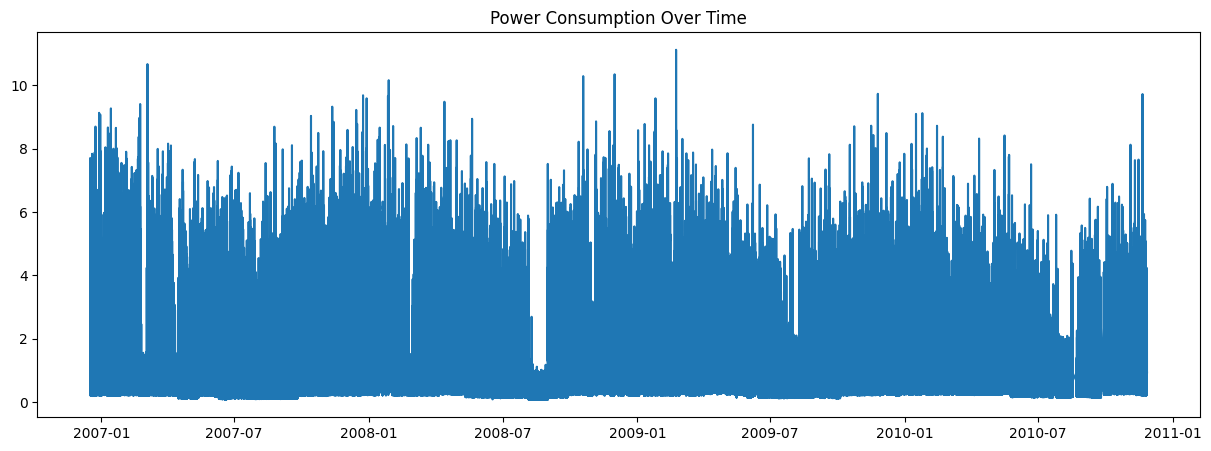

In [15]:
plt.figure(figsize=(15,5))
plt.plot(df["Datetime"], df["Global_active_power"])
plt.title("Power Consumption Over Time")
plt.show()

Distribution of Global active power

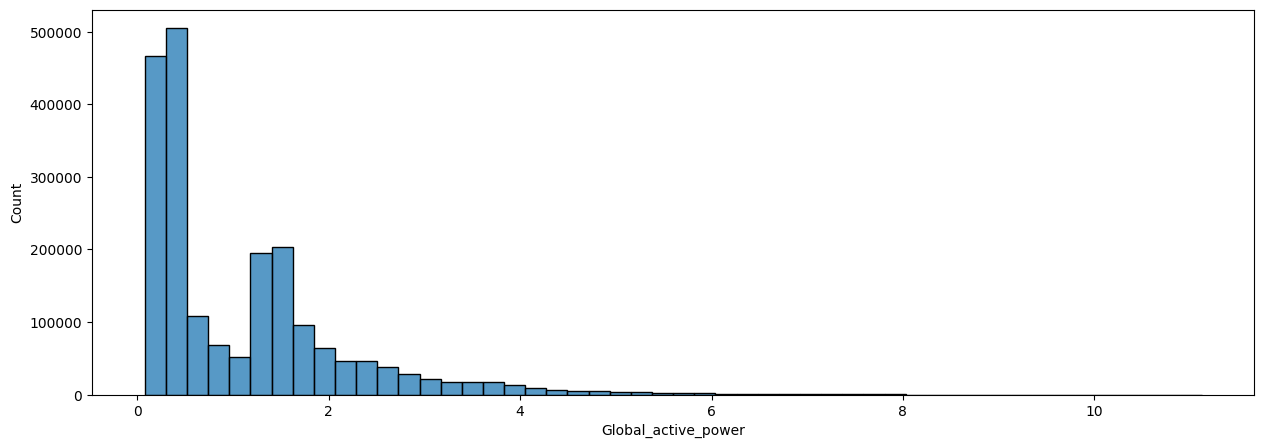

In [16]:
plt.figure(figsize = (15, 5))

sns.histplot(df['Global_active_power'], bins = 50)
plt.show()

Global active power - Hourly Pattern

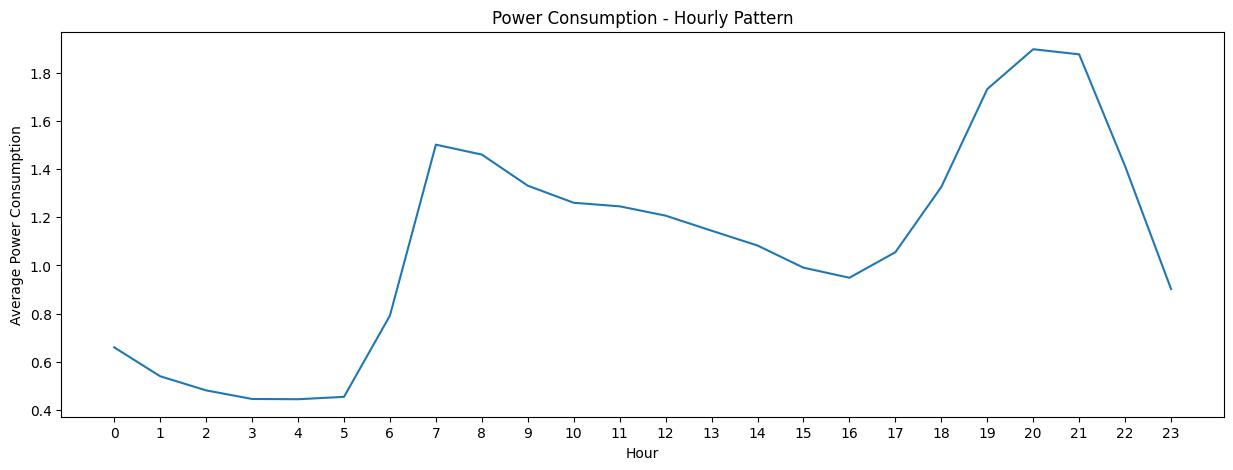

In [17]:
hourly_data = df.groupby(df['Hour'])['Global_active_power'].mean()

plt.figure(figsize = (15, 5))
plt.plot(hourly_data.index, hourly_data.values)
plt.xlabel('Hour')
plt.xticks(range(0, 24))
plt.ylabel('Average Power Consumption')
plt.title('Power Consumption - Hourly Pattern')
plt.show()

Power Consumption - Weekly Pattern

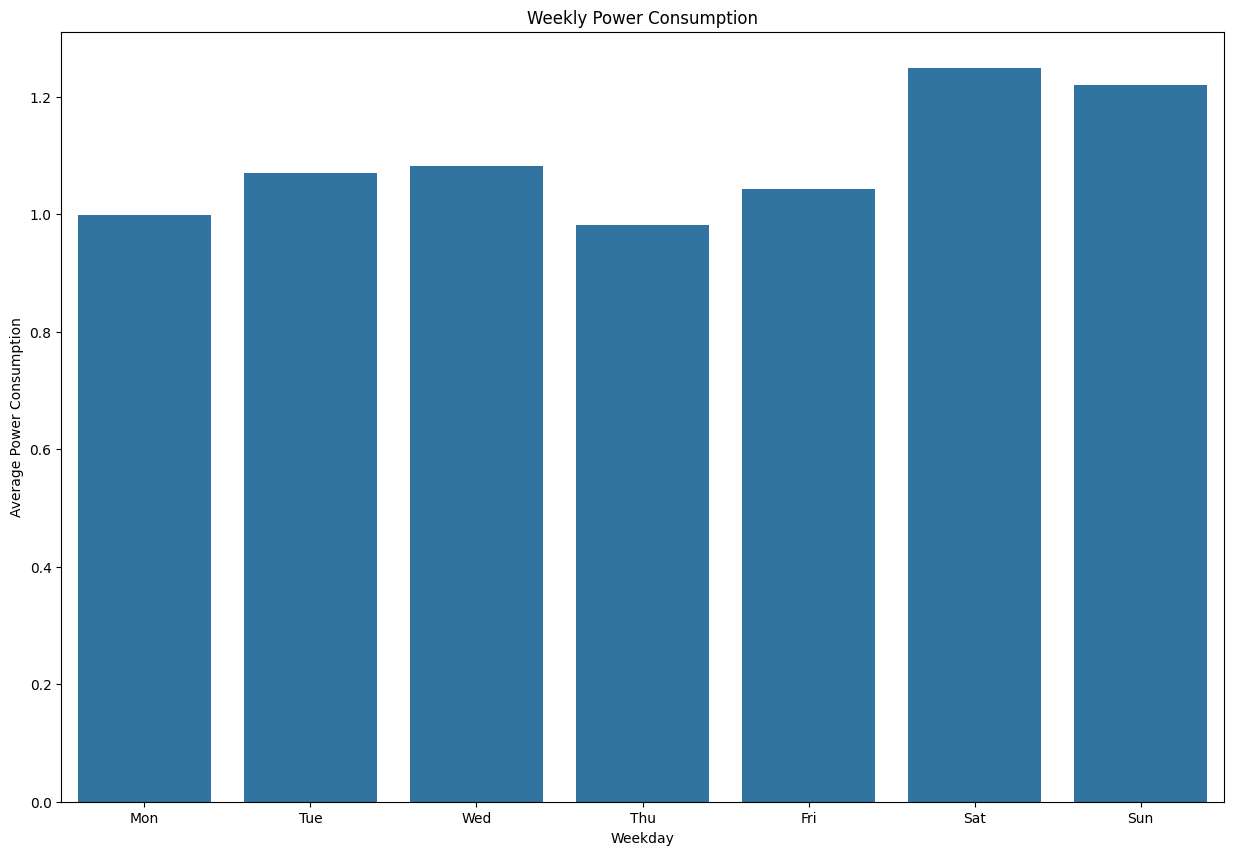

In [18]:
weekly_data = df.groupby(df['Weekday'])['Global_active_power'].mean()

plt.figure(figsize=(15, 10))
sns.barplot(x = weekly_data.index, y = weekly_data.values)
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.ylabel('Average Power Consumption')
plt.title('Weekly Power Consumption')
plt.show()

Power Consumption - Monthly Pattern

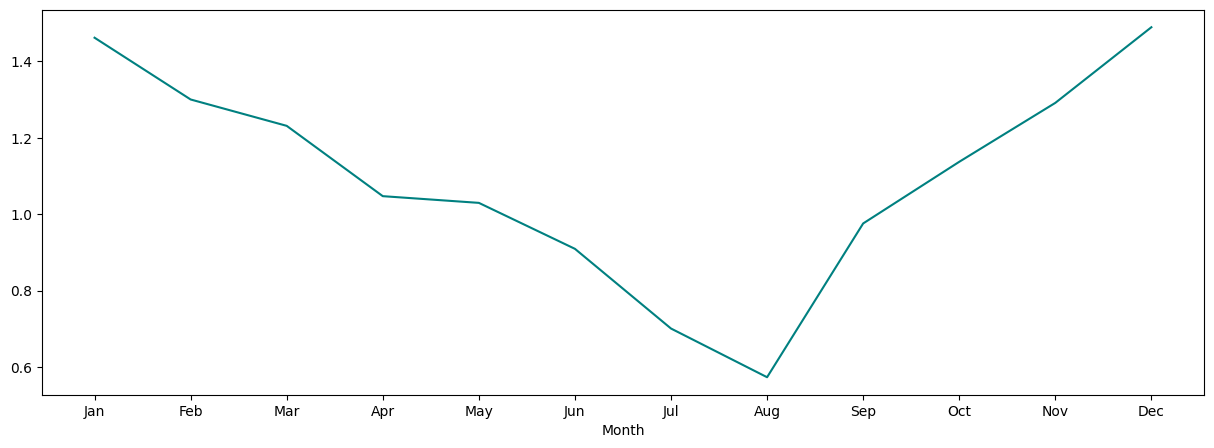

In [19]:
monthly_data = df.groupby(df['Month'])['Global_active_power'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize = (15, 5))

sns.lineplot(x= monthly_data.index, y=monthly_data.values, color='teal')
plt.xticks(range(1, 13), month_names)

plt.show()

Power Consumption - Year over Year Monthly Trend

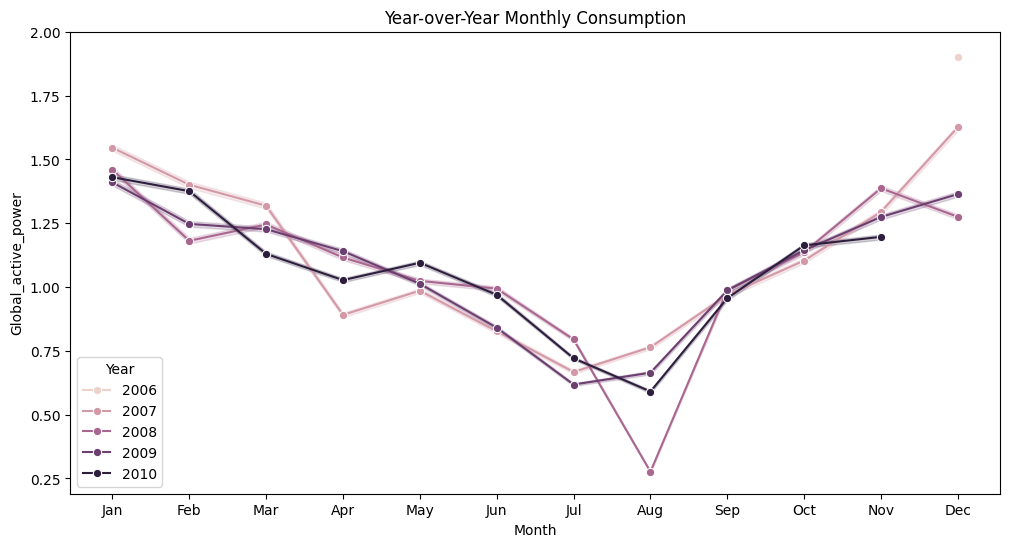

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Month', y='Global_active_power', hue='Year', marker='o')
plt.title('Year-over-Year Monthly Consumption')
plt.xticks(range(1, 13), month_names)
plt.show()

Global reactive power over time

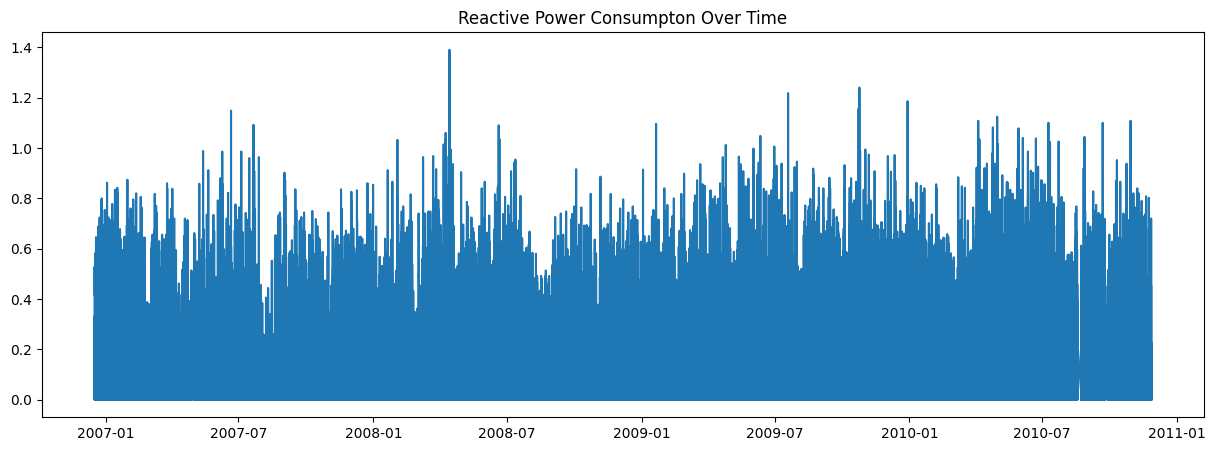

In [21]:
plt.figure(figsize=(15,5))
plt.plot(df["Datetime"], df["Global_reactive_power"])
plt.title("Reactive Power Consumpton Over Time")
plt.show()

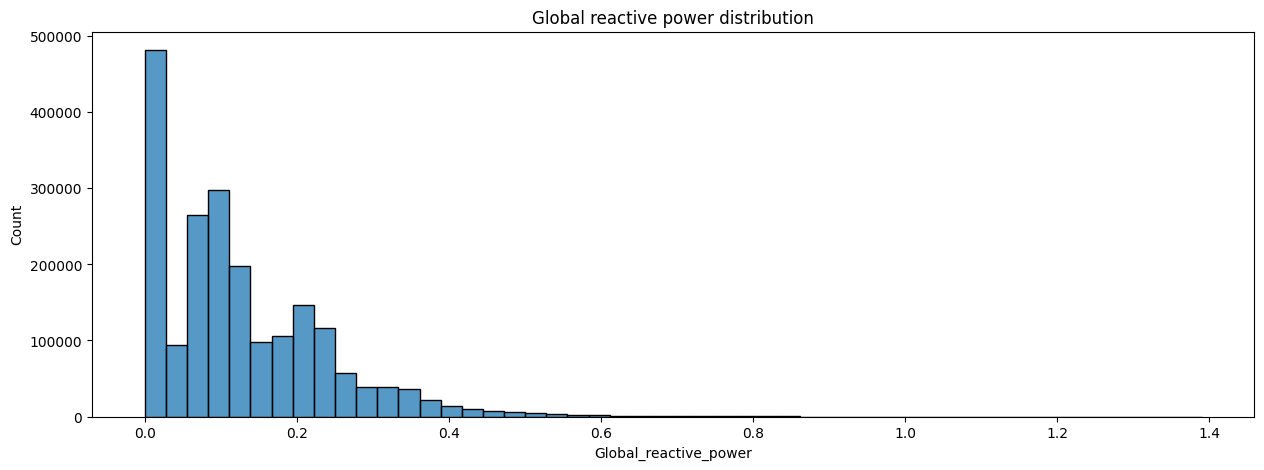

In [22]:
plt.figure(figsize = (15, 5))

sns.histplot(df['Global_reactive_power'], bins = 50)
plt.title('Global reactive power distribution')
plt.show()

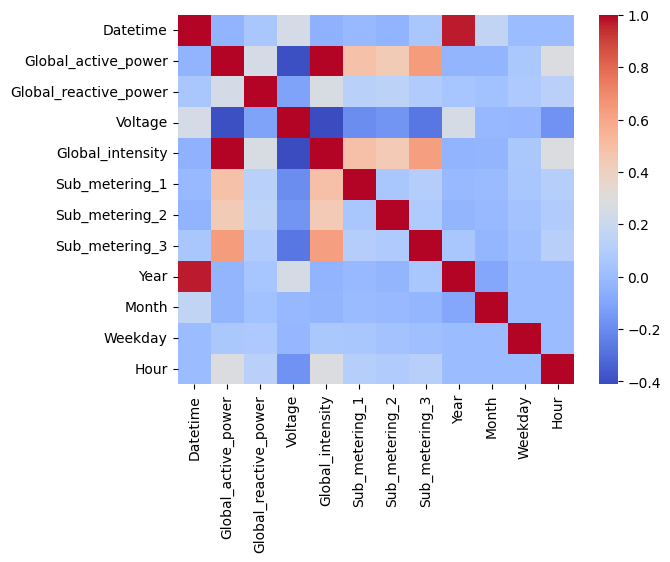

In [23]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap = 'coolwarm')
plt.show() 